In [1]:
import pandas as pd
import numpy as np


from sklearn.metrics import matthews_corrcoef

from sklearn.model_selection import train_test_split
import getting_threshold_genes as gtg
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from ydata_profiling import ProfileReport
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score


from sklearn.metrics import make_scorer, matthews_corrcoef
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

from sklearn.metrics import make_scorer, matthews_corrcoef
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

In [2]:
eigth_bins_original = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_SMOTE_train.csv")
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_SMOTE_test.csv")
eigth_bins_original=eigth_bins_original[eigth_bins_original["Experiment"]=="GSE167186"]
eigth_bins_test=eigth_bins_test[eigth_bins_test["Experiment"]=="GSE167186"]
seq_metadata_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/All_rna_samples_metadata_edit.csv"
seq_metadata = pd.read_csv(seq_metadata_path)
rnaSeq_origial= pd.merge(eigth_bins_original, seq_metadata, on='Sample', how='inner')
rnaSeq_test= pd.merge(eigth_bins_test, seq_metadata, on='Sample', how='inner')
x_labels= rnaSeq_origial["Status"].value_counts()


In [3]:
rnaSeq_origial["Age_C"] = np.where(rnaSeq_origial["Age"] > 65, "Old", "Young")
rnaSeq_origial["Class"]=rnaSeq_origial["Status"].astype(str) +" "+ rnaSeq_origial["Age_C"].astype(str)

rnaSeq_test["Age_C"] = np.where(rnaSeq_test["Age"] > 65, "Old", "Young")
rnaSeq_test["Class"]=rnaSeq_test["Status"].astype(str) +" "+ rnaSeq_test["Age_C"].astype(str)
scorer = make_scorer(matthews_corrcoef)


In [4]:
print("Training:",len(eigth_bins_original), "Testing:",len(eigth_bins_test))

Training: 43 Testing: 32


In [5]:
ridge_selection = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_2_feature_selection.csv"
df = gtg.get_df(ridge_selection)# alpha=0.05
rnaseq_genes = df["Ensembl"]
len(rnaseq_genes)
rnaseq_genes = rnaseq_genes.to_list()

rnaseq_genes.append("Status")

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
0.0860871588773362


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/numpy/lib/polynomial.py:668: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


In [6]:
rnaseq_genes

['ENSG00000252287.1',
 'ENSG00000211844.1',
 'ENSG00000189058.8',
 'ENSG00000270388.1',
 'ENSG00000252456.1',
 'ENSG00000212571.1',
 'ENSG00000199455.1',
 'ENSG00000004866.20',
 'ENSG00000255633.5',
 'ENSG00000198840.2',
 'ENSG00000201968.1',
 'ENSG00000232177.1',
 'ENSG00000173212.4',
 'ENSG00000277203.1',
 'ENSG00000169057.21',
 'ENSG00000200238.1',
 'ENSG00000272134.1',
 'ENSG00000136238.17',
 'ENSG00000226306.6',
 'ENSG00000252516.1',
 'ENSG00000198786.2',
 'ENSG00000200468.1',
 'ENSG00000101204.16',
 'ENSG00000173068.17',
 'ENSG00000233494.1',
 'ENSG00000201708.1',
 'ENSG00000201920.1',
 'ENSG00000005339.14',
 'ENSG00000127720.7',
 'ENSG00000275387.1',
 'ENSG00000264497.1',
 'ENSG00000284840.1',
 'ENSG00000185885.15',
 'ENSG00000198695.2',
 'ENSG00000232989.1',
 'ENSG00000252070.1',
 'ENSG00000201440.1',
 'ENSG00000256892.2',
 'ENSG00000273173.5',
 'ENSG00000252512.1',
 'ENSG00000143226.13',
 'ENSG00000251890.1',
 'ENSG00000201856.1',
 'ENSG00000251760.1',
 'ENSG00000251936.1',
 '

In [ ]:
top_35_genes_age = ["ENSG00000101892.11",
"ENSG00000277654.5",
"ENSG00000127241.16",
"ENSG00000171055.14",
"ENSG00000170873.18",
"ENSG00000137700.17",
"ENSG00000177548.12",
"ENSG00000123095.5",
"ENSG00000111640.14",
"ENSG00000127184.12",
"ENSG00000089101.17",
"ENSG00000101745.16",
"ENSG00000082397.17",
"ENSG00000178053.17",
"ENSG00000227097.5",
"ENSG00000185760.15",
"ENSG00000145675.14",
"ENSG00000124370.10",
"ENSG00000130935.9",
"ENSG00000185551.14",
"ENSG00000270388.1",
"ENSG00000131378.13",
"ENSG00000222427.1",
"ENSG00000150722.10",
"ENSG00000112562.18",
"ENSG00000169083.16",
"ENSG00000133315.10",
"ENSG00000177508.11",
"ENSG00000182108.10",
"ENSG00000199455.1",
"ENSG00000085231.13",
"ENSG00000238391.1",
"ENSG00000112031.15",
"ENSG00000188176.11",
"ENSG00000069275.12",
"Status"
]



In [7]:
rige_shap_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_2_8_Ridge_seq_RIDGE_regressor_genes.csv"
#rige_shap = pd.read_csv(rige_shap_path)
#rige_shap.columns = ["Ensembl", "Importance", "abs_coef"]
rige_shap_top = gtg.get_df(rige_shap_path)

top_35_genes_age = rige_shap_top["Ensembl"].to_list()

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
0.742314764497012


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/numpy/lib/polynomial.py:668: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


In [10]:
top_35_genes_age.extend(["Sample", "Status", "Age","Sex", "Age_C", "Class", "Experiment"])
rnaseq_genes.extend(["Sample", "Status","Age","Sex", "Age_C", "Class", "Experiment"])

In [11]:
remove_youn = rnaSeq_origial[rnaSeq_origial["Age_C"]!="Young"]
#remove_youn = rnaSeq_origial[rnaSeq_origial["Class"]!="Healthy Old"]
#rnaseq_genes.extend(["Sample", "Age","Sex", "Age_C", "Class", "Experiment"])
remove_youn = remove_youn[rnaseq_genes]

remove_youn=remove_youn[top_35_genes_age]

In [17]:
remove_youn.drop(columns=["Status"], inplace=True)
remove_youn["Status"]= rnaSeq_origial["Status"]
remove_youn.head()

,ENSG00000035664.11,ENSG00000160294.10,ENSG00000197111.15,ENSG00000167186.10,ENSG00000250479.8,ENSG00000276045.3,ENSG00000105323.16,ENSG00000252598.1,ENSG00000197563.10,ENSG00000164093.16,...,ENSG00000095787.21,ENSG00000146147.14,ENSG00000123095.5,Sample,Age,Sex,Age_C,Class,Experiment,Status
0,0.017613,-0.003599,0.193562,-0.007877,0.249511,-0.005606,0.005828,-0.025231,0.140946,0.000409,...,0.015128,0.027263,0.063013,SRR13758996,77.0,NaN,Old,Sarcopenia Old,GSE167186,Sarcopenia
1,0.017425,-0.004504,0.192372,-0.008885,0.257891,-0.007292,0.005982,-0.026308,0.142666,0.000192,...,0.010220,0.028494,0.005996,SRR13759017,71.0,NaN,Old,Sarcopenia Old,GSE167186,Sarcopenia
5,0.017706,-0.003926,0.188955,-0.008694,0.248221,-0.005801,0.006201,-0.025273,0.142021,0.003058,...,0.014284,0.025381,-0.012013,SRR13759035,71.0,NaN,Old,Sarcopenia Old,GSE167186,Sarcopenia
6,0.017854,-0.003603,0.199231,-0.008677,0.257745,-0.006073,0.005766,-0.025295,0.141994,0.000861,...,0.009442,0.025701,0.012514,SRR13758987,83.0,NaN,Old,Sarcopenia Old,GSE167186,Sarcopenia
8,0.017321,-0.003974,0.192726,-0.009196,0.256258,-0.005679,0.007166,-0.026120,0.144100,0.001728,...,0.013743,0.032413,0.014614,SRR13759076,75.0,NaN,Old,Sarcopenia Old,GSE167186,Sarcopenia


In [13]:
remove_youn["Class"].value_counts()

Class
Sarcopenia Old    15
Healthy Old       14
Name: count, dtype: int64

In [18]:
#import feature_selection as fs
#section_df = remove_youn.drop(columns=["Sample", "Status", "Age","Sex", "Age_C", "Class", "Experiment"])
#section_df_age = remove_youn["Status"]
#features, status = fs.smote(X=section_df, y=section_df_age)
#remove_youn = pd.DataFrame(features, columns=section_df.columns)
#remove_youn["Status"] = status
remove_youn["Status"].value_counts()

Status
Sarcopenia    15
Healthy       14
Name: count, dtype: int64

In [22]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = train_test_split(remove_youn.drop(["Sample", "Status", "Age","Sex", "Age_C", "Class", "Experiment"], axis=1), remove_youn["Status"], remove_youn, test_size=0.01, random_state=42)
#seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = train_test_split(remove_youn.drop(["Status"], axis=1), remove_youn["Status"], remove_youn, test_size=0.4, random_state=42)


In [23]:
print("X_train shape: ", seq_X_train.shape, "X_test shape: ", seq_X_test.shape, "y_train shape: ", seq_y_train.shape, "y_test shape: ", seq_y_test.shape, "z_train shape: ", seq_z_train.shape, "z_test shape: ", seq_z_test.shape)
print("Train Healthy: ", seq_y_train.value_counts(), "Test Sarcopenia: ", seq_y_test.value_counts())

X_train shape:  (28, 31) X_test shape:  (1, 31) y_train shape:  (28,) y_test shape:  (1,) z_train shape:  (28, 38) z_test shape:  (1, 38)
Train Healthy:  Status
Healthy       14
Sarcopenia    14
Name: count, dtype: int64 Test Sarcopenia:  Status
Sarcopenia    1
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
scorer = make_scorer(matthews_corrcoef)
seq_y_train = seq_y_train.replace({"Healthy": 0, "Sarcopenia": 1})
seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100, 1000, 10000, 100000],  # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001],  # Kernel coefficient for 'rbf' and 'poly'
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],  # Kernel type
}

# Create SVM model
svm_model = SVC()

# Perform grid search with cross-validation
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring=scorer)
grid_search.fit(seq_X_train, seq_y_train)

# Get best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score (mcc):", best_score)

# Use best model for prediction
best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(seq_X_test)
y_pred

/tmp/ipykernel_89484/2028479386.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  seq_y_train = seq_y_train.replace({"Healthy": 0, "Sarcopenia": 1})
/tmp/ipykernel_89484/2028479386.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})


Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Score (mcc): 0.2938684296260891


array([0])

In [25]:
remove_youn = rnaSeq_origial[rnaSeq_origial["Age_C"]!="Young"]
#remove_youn = rnaSeq_origial[rnaSeq_origial["Class"]!="Healthy Old"]
#rnaseq_genes.extend(["Sample", "Age","Sex", "Age_C", "Class", "Experiment"])
remove_youn = remove_youn[rnaseq_genes]

#remove_youn=remove_youn[top_35_genes_age]

In [26]:
test_data = rnaSeq_test[rnaSeq_test["Age_C"]!="Young"]
#test_data = rnaSeq_test[rnaSeq_test["Class"]!="Healthy Old"]
#rnaseq_genes.extend(["Sample", "Age"])
test_data = test_data[rnaseq_genes]
test_data=test_data[top_35_genes_age]
test_data = test_data.T.drop_duplicates().T
test_data["Class"].value_counts()


Class
Healthy Old       14
Sarcopenia Old     8
Name: count, dtype: int64

In [27]:
test_data.columns[-15:]

Index(['ENSG00000167244.19', 'ENSG00000185915.5', 'ENSG00000197223.11',
       'ENSG00000132530.16', 'ENSG00000257542.5', 'ENSG00000095787.21',
       'ENSG00000146147.14', 'ENSG00000123095.5', 'Sample', 'Status', 'Age',
       'Sex', 'Age_C', 'Class', 'Experiment'],
      dtype='object')

In [39]:
seq_X_test = test_data.drop(columns=["Sample","Status", 'Sample', 'Age','Sex', 'Age_C', 'Class', 'Experiment'])
seq_y_test = test_data["Status"]
seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})

/tmp/ipykernel_89484/3736171106.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  seq_y_test = seq_y_test.replace({"Healthy": 0, "Sarcopenia": 1})


In [40]:
seq_X_test.shape

(22, 31)

In [41]:
best_svm_model = grid_search.best_estimator_


In [42]:
y_pred = best_svm_model.predict(seq_X_train)

conf_matrix_train = confusion_matrix(seq_y_train, y_pred)
print(conf_matrix_train)

[[13  1]
 [ 9  5]]


In [43]:

y_pred = best_svm_model.predict(seq_X_test)
print("Test Labels:", seq_y_test.values)
print("Predicted Labels:", y_pred)
mcc = matthews_corrcoef(seq_y_test, y_pred)
print("MCC:", mcc)
conf_matrix_test = confusion_matrix(seq_y_test, y_pred)
print(conf_matrix_test)

Test Labels: [1 0 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0]
Predicted Labels: [0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
MCC: -0.025031308716087945
[[12  2]
 [ 7  1]]


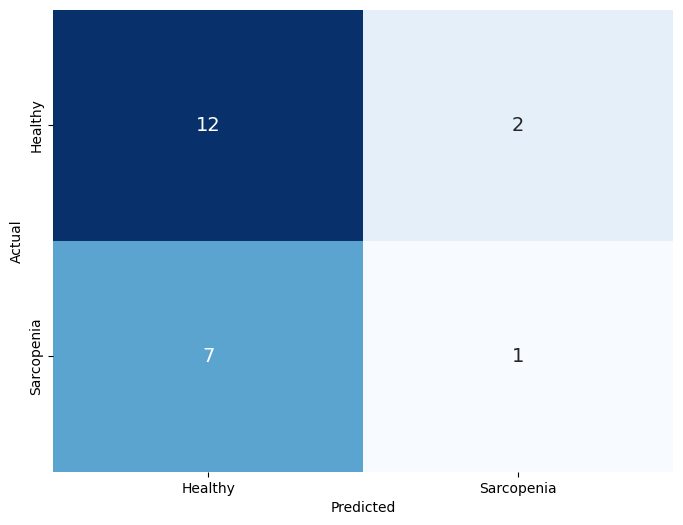

In [44]:
from matplotlib import pyplot as plt
import seaborn as sns

x_labels = ['Healthy', 'Sarcopenia']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True, cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
#plt.title('Confusion Matrix')

plt.show()

In [ ]:
sen = recall_score(seq_y_test, y_pred)
spc = recall_score(seq_y_test, y_pred, pos_label=0)
mcc = matthews_corrcoef(seq_y_test, y_pred)
ppv = precision_score(seq_y_test, y_pred)
npv = precision_score(seq_y_test, y_pred, pos_label=0)
f1 = f1_score(seq_y_test, y_pred)
print("Sensitivity:", sen)
print("Specificity:", spc)
print("PPV:", ppv)
print("NPV:", npv)
print("F1 Score:", f1)
print("MCC:", mcc)


In [ ]:
auc = roc_auc_score(seq_y_test, y_pred)
print("AUC:", auc)

In [ ]:
resolutuion_df = pd.DataFrame(seq_X_test)
resolutuion_df["Status"] = seq_y_test
resolutuion_df["Predicted"] = y_pred
resolutuion_df["Sample"] = seq_z_test["Sample"]

In [ ]:
resolutuion_df#[resolutuion_df["Predicted"]!=resolutuion_df["Status"]]

In [ ]:
def spcy(seq_y_test, y_pred):
    spc = precision_score(seq_y_test, y_pred)
    return spc